# PART2_phenotype_stats
Check distribution of phenotype values for each RIL

Check correlations between traits

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set()
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

# check phenotype distribution
# Traits: LW, LL, DTH, PN, GN, GS

<ipython-input-2-282689ba71b0>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  founder_data["RIL"] = founder_data.index.str[:3]
<ipython-input-2-282689ba71b0>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hitome_data["RIL"] = Hitome_data.index.str[:3]
<ipython-input-2-282689ba71b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

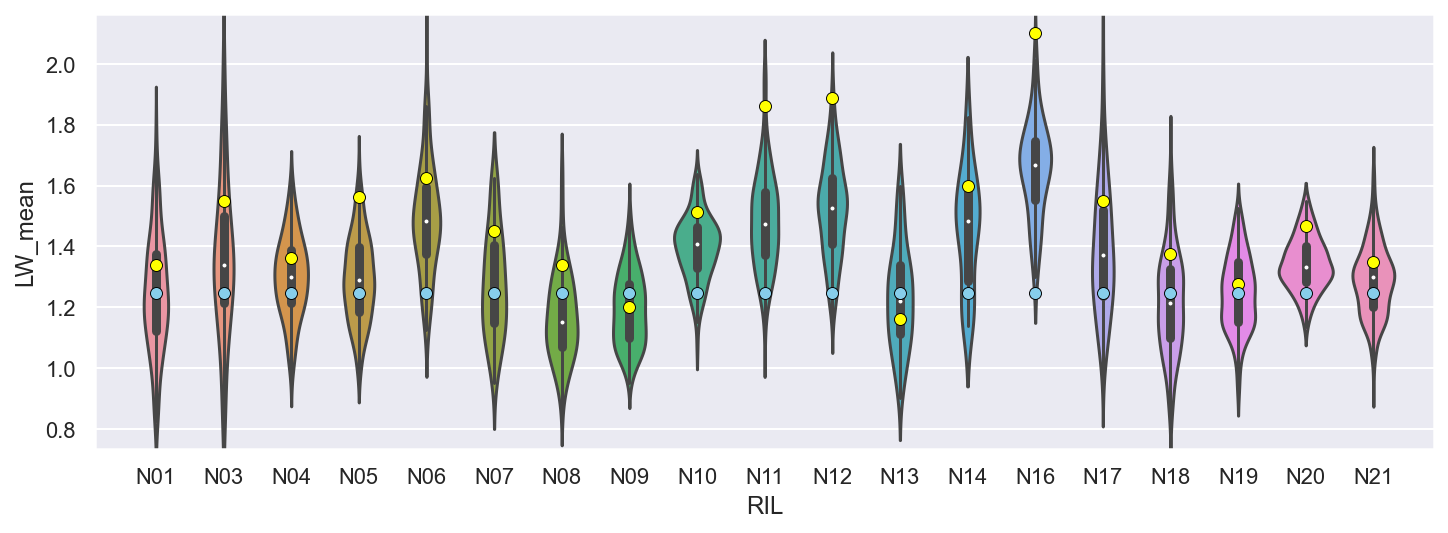

<ipython-input-2-282689ba71b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hitome_data[i] = Hitome_data[i].mean()


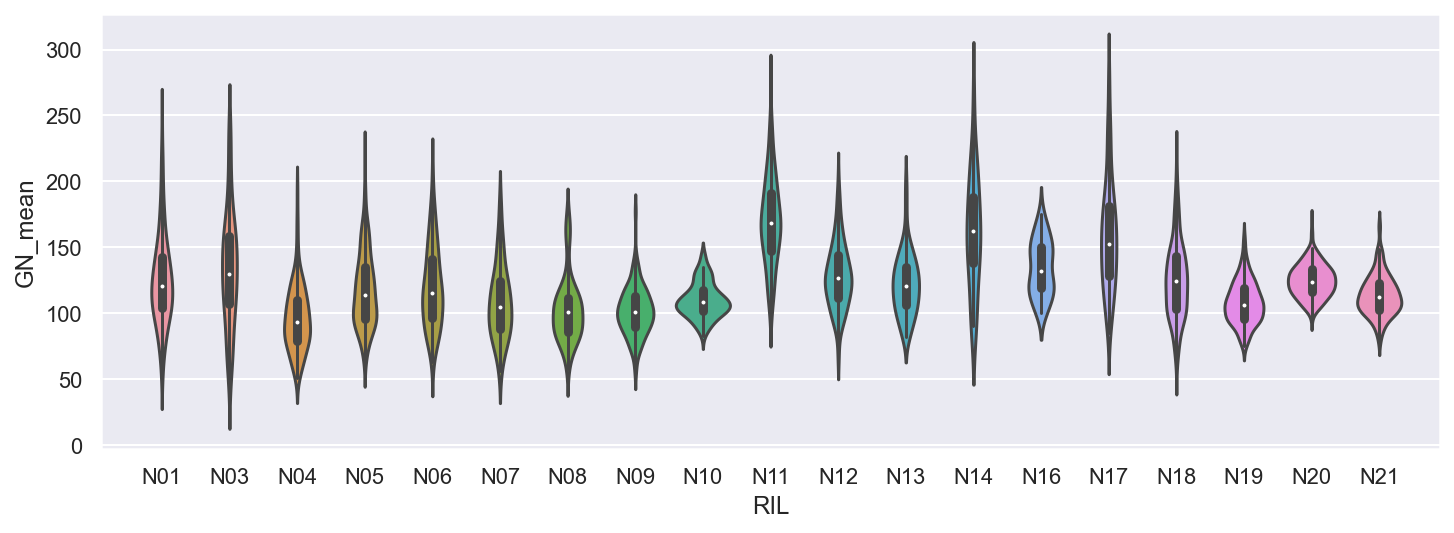

<ipython-input-2-282689ba71b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hitome_data[i] = Hitome_data[i].mean()


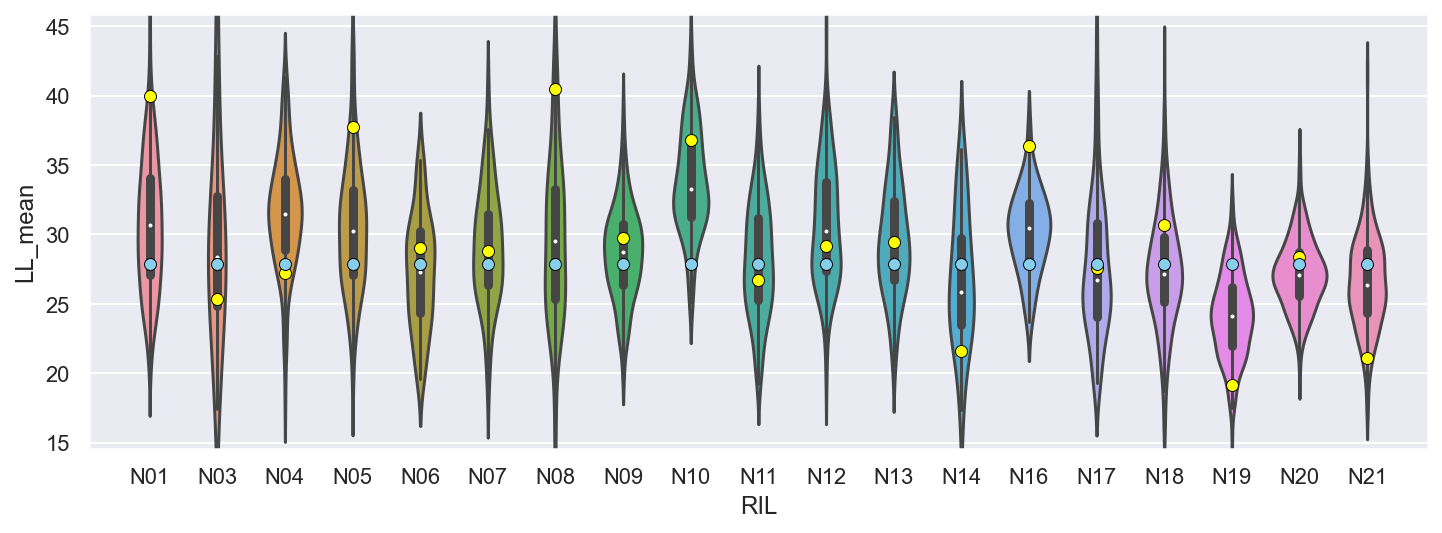

<ipython-input-2-282689ba71b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hitome_data[i] = Hitome_data[i].mean()


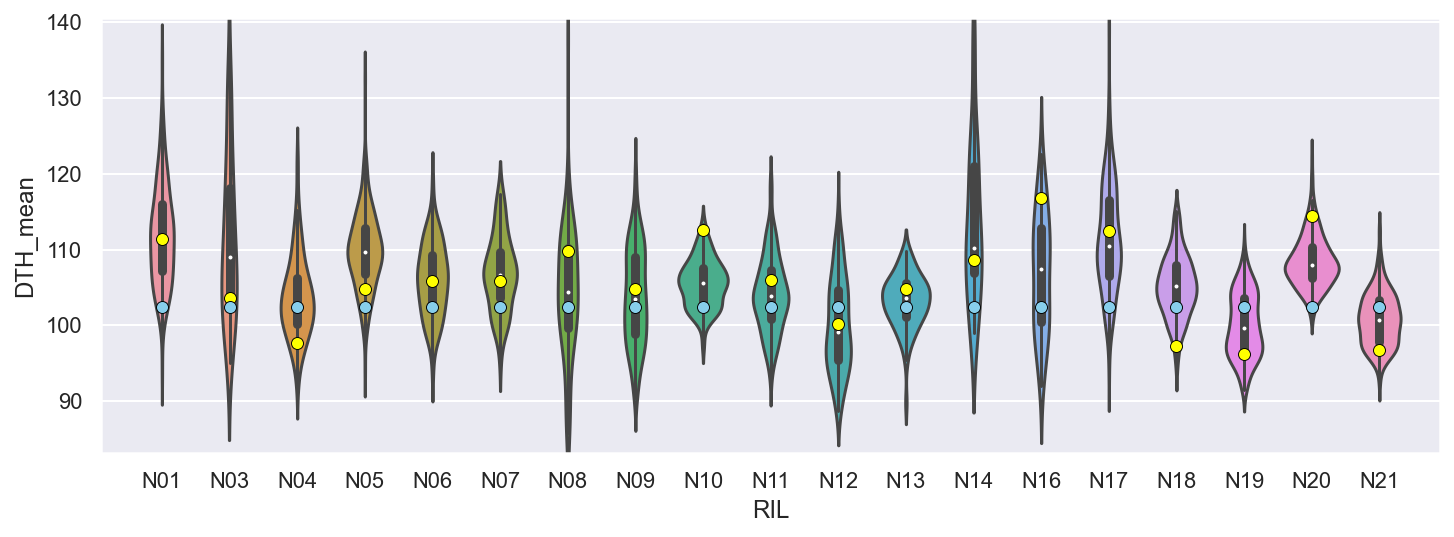

<ipython-input-2-282689ba71b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hitome_data[i] = Hitome_data[i].mean()


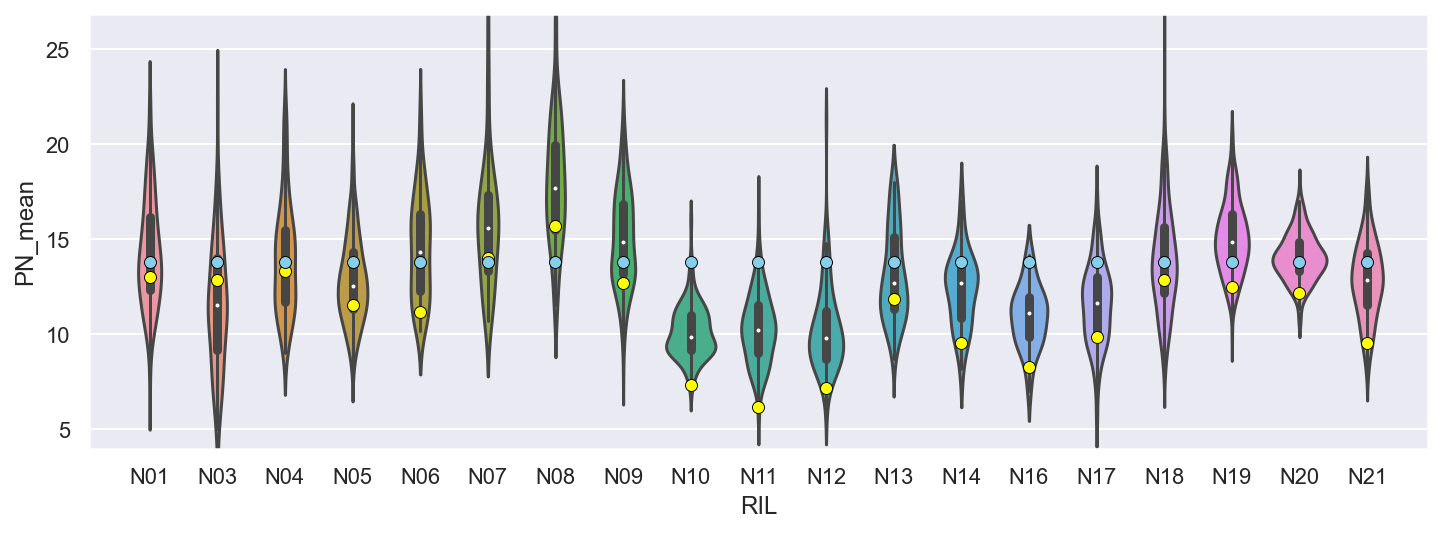

<ipython-input-2-282689ba71b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hitome_data[i] = Hitome_data[i].mean()


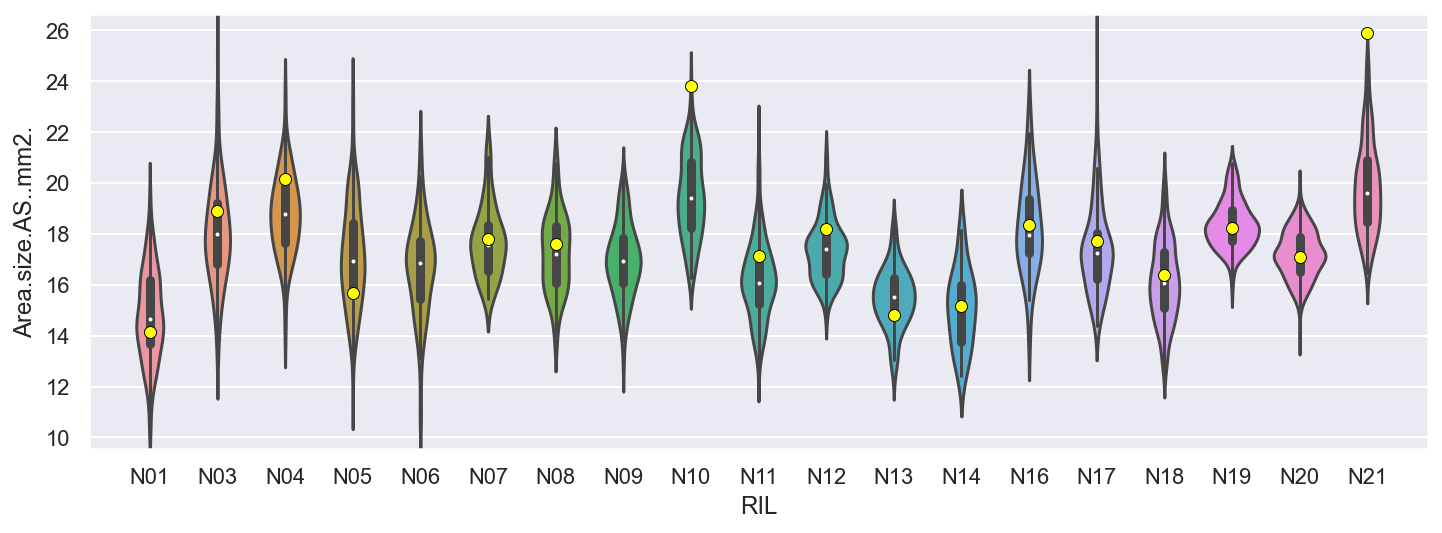

In [2]:
phenotype_data = pd.read_csv("../data/phenotype_data/mean_phenotypes.csv", index_col=0)
parents_data = pd.read_csv("../data/phenotype_data/mean_phenotypes_parents.csv", index_col=0)
founder_data = parents_data.loc[(parents_data.index.str.contains("999")) & (~parents_data.index.str.contains("N22")), :]
founder_data["RIL"] = founder_data.index.str[:3]
Hitome_data = parents_data.loc[(parents_data.index.str.contains("000")) & (~parents_data.index.str.contains("N22")), :]
Hitome_data["RIL"] = Hitome_data.index.str[:3]

for i in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    tmp_data = phenotype_data.loc[:, ["Line", i]]
    tmp_data["RIL"] = tmp_data.Line.str[:3]
    Hitome_data[i] = Hitome_data[i].mean()

    fig = plt.figure(figsize=(12,4))
    ax = fig.add_subplot(1, 1, 1)
    sns.violinplot(x='RIL', y=i, data=tmp_data, jitter=True, ax=ax)
#     sns.stripplot(x="RIL", y=i, data=tmp_data, jitter=True)
    sns.scatterplot(x='RIL', y=i, data=founder_data, ax=ax, zorder=10, color="yellow", edgecolor="black")
    sns.scatterplot(x='RIL', y=i, data=Hitome_data, ax=ax, zorder=10, color="skyblue", edgecolor="black")
    
    ax.set_xlabel('RIL')
    ax.set_ylabel(i)
    plt.show()

# Trade-off relationships

* Grain Number vs Panicle Number
* Panicle Number vs Grain Size
* Grain size vs Grain number
* Grain Number vs Panicle Number vs Grain size
* Grain Number vs Panicle Number vs Grain size * Panicle number

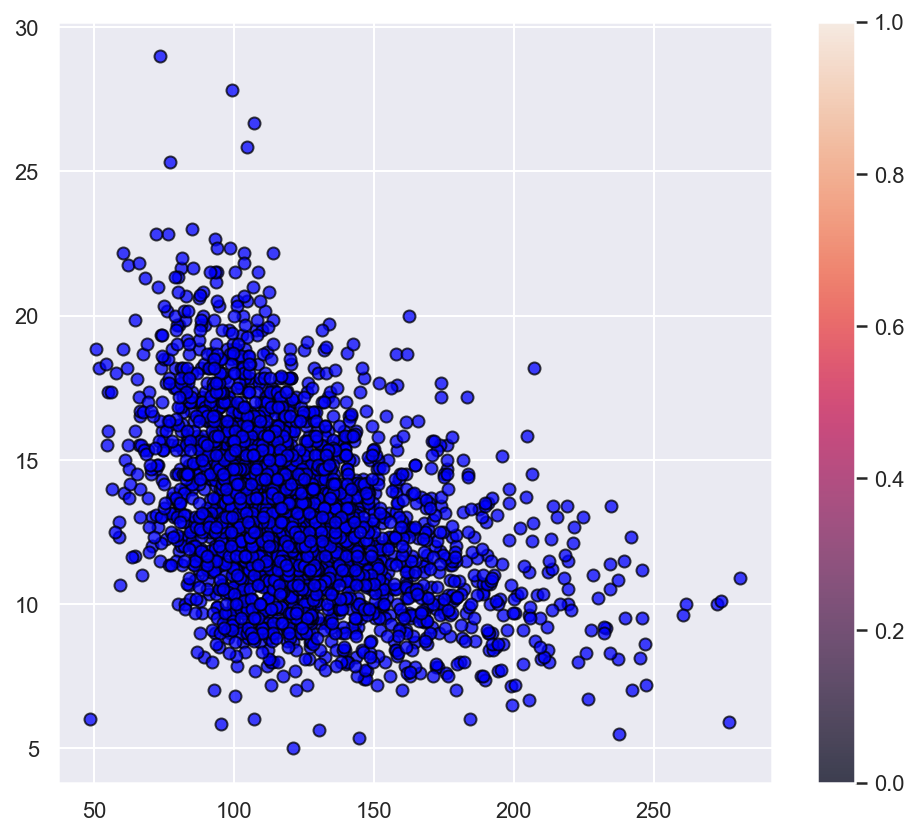

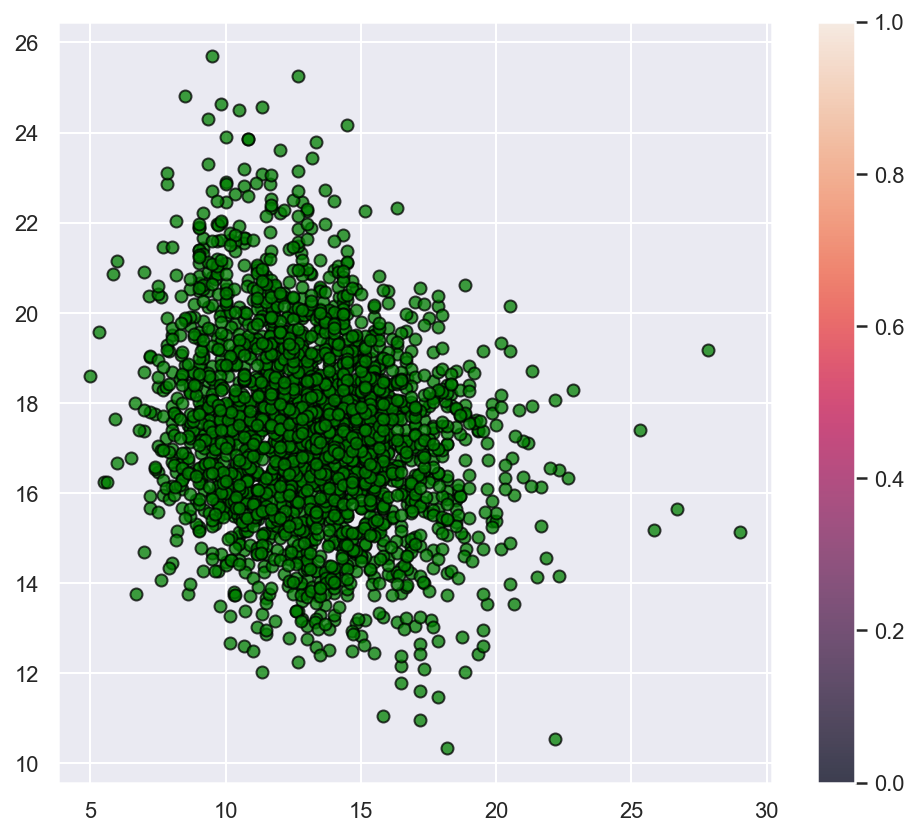

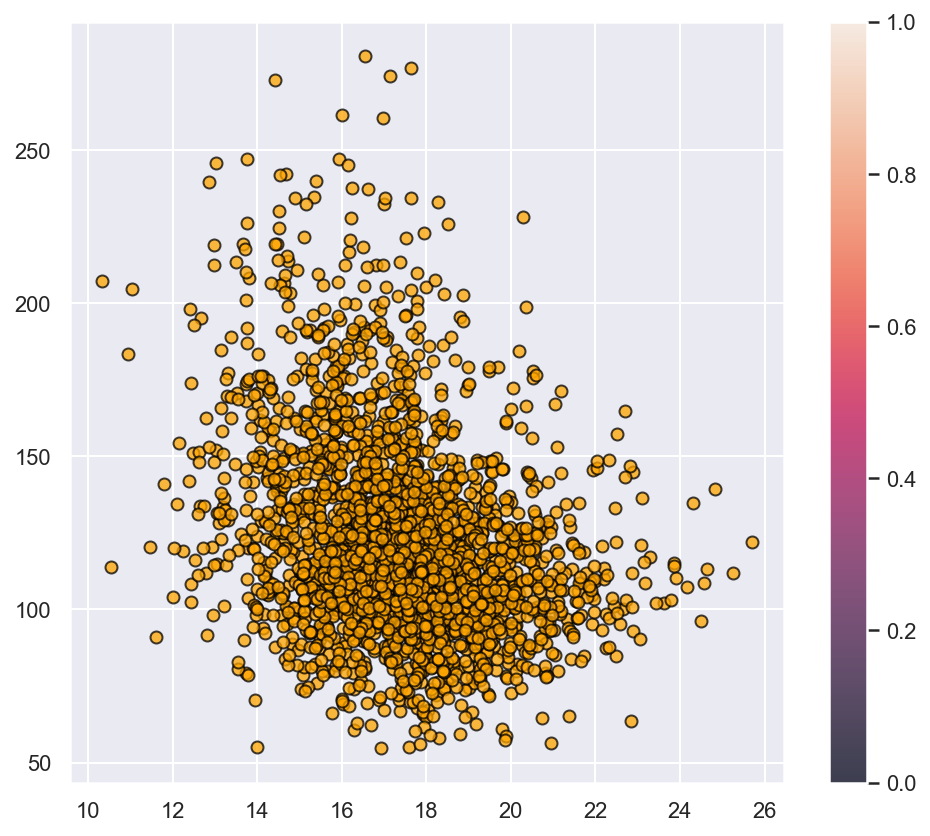

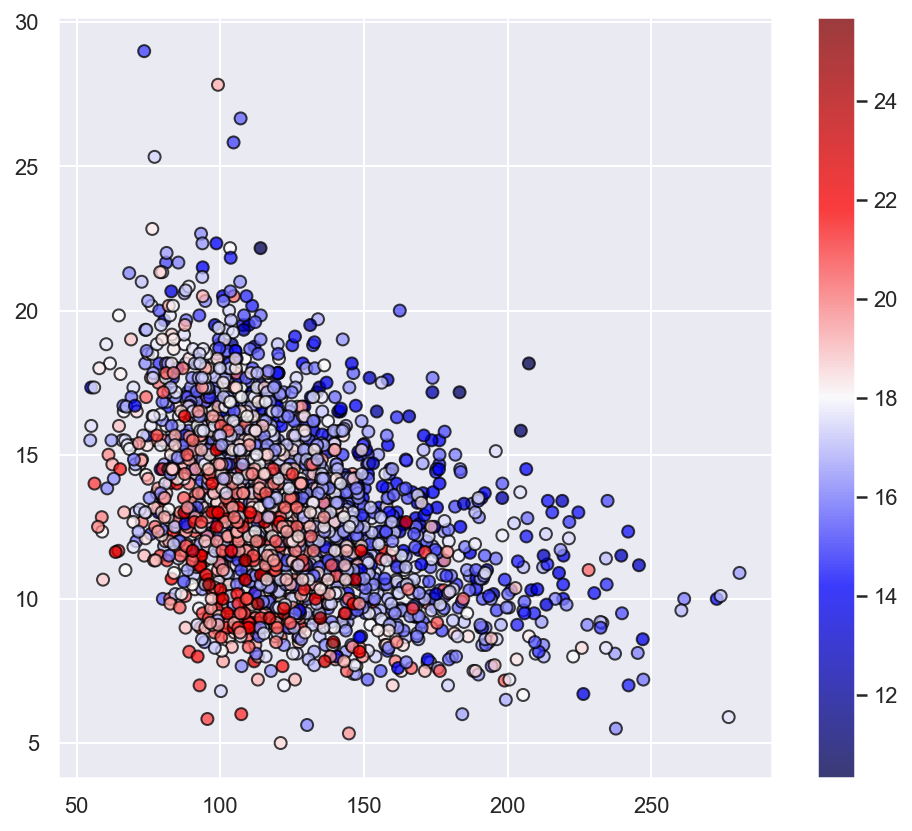

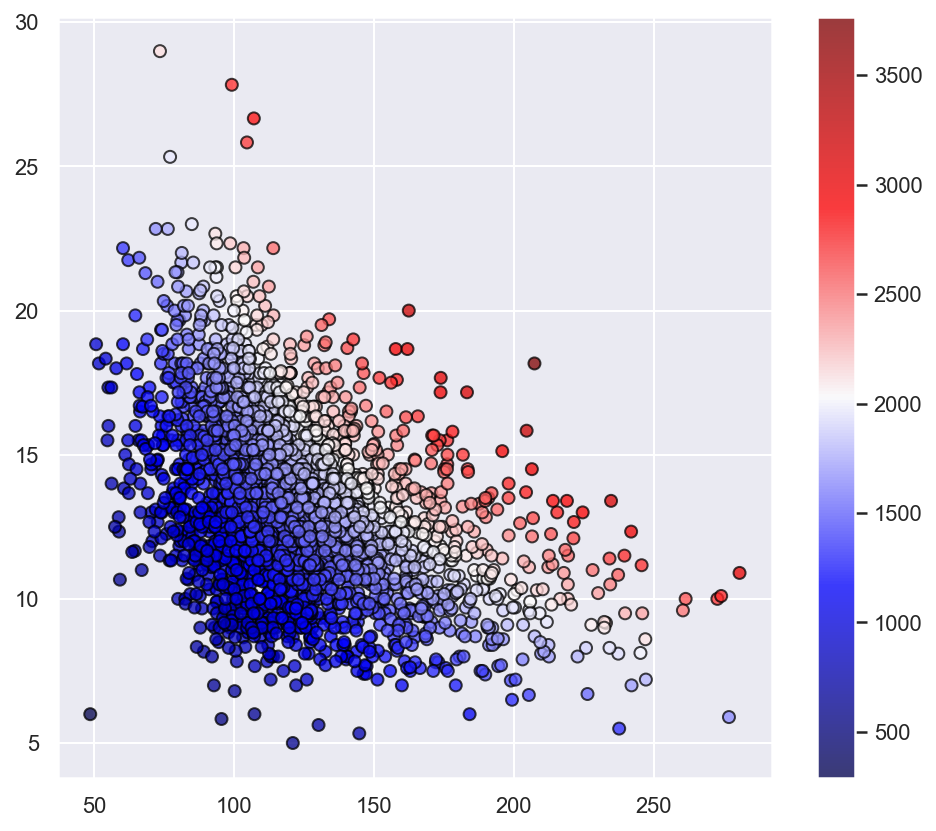

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# from cmcrameri import cm
import seaborn as sns
import copy
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], c="blue", alpha=0.75, edgecolor="black")
plt.colorbar(sc)
plt.show()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["PN_mean"], phenotype_data["Area.size.AS..mm2."], c="green", alpha=0.75, edgecolor="black")
plt.colorbar(sc)
plt.show()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["Area.size.AS..mm2."], phenotype_data["GN_mean"], c="orange", alpha=0.75, edgecolor="black")
plt.colorbar(sc)
plt.show()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], c=phenotype_data["Area.size.AS..mm2."], alpha=0.75, edgecolor="black", cmap=cm.seismic)
plt.colorbar(sc)
plt.show()


plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], c=phenotype_data["GN_mean"]*phenotype_data["PN_mean"], alpha=0.75, edgecolor="black", cmap=cm.seismic)
plt.colorbar(sc)
plt.show()